# DLinear reproduction on Traffic (validating the app's implementation)

**Goal.** Show that the DLinear used by the app (`backend/app/forecasting/models/dlinear.py`) is
implemented correctly by reproducing the Traffic results of *Are Transformers Effective for Time
Series Forecasting?* (Zeng et al., AAAI-23, `docs/Dlinear.pdf`, Table 2).

**Approach.** The network class is **imported from the app** (`_DLinearNet`), not rewritten. Only the
*experimental protocol* is switched to the paper's:

| | Paper (Table 2) | App (`period_split` + `experiment_runner`) |
|---|---|---|
| Variables | all 862 sensors | first 50 |
| Split | 70 / 10 / 20 chronological | last `test_periods * period` rows = test, rest = train |
| Scaler | z-score fit on the 70 % train part | z-score fit on all pre-test data |
| Lookback L | **336** (section 6b: the paper's Linear numbers reproduce at 336, not at 96) | `input_periods * period` |
| Horizons T | 96, 192, 336, 720 | `(test_periods - input_periods) * period` |
| Test set | **every** sliding window of the test split (about 3,400 windows) | **one** window |
| Metric | MSE / MAE on normalized data, pooled | same formula, but on that one window |

Paper values for DLinear on Traffic: MSE/MAE = 0.410/0.282, 0.423/0.287, 0.436/0.296, 0.466/0.315
for T = 96/192/336/720.

The last sections evaluate the *same trained model* with the app's single-window protocol, and with
only 50 sensors, to show where the app's different (often lower) MSE comes from.

In [1]:
import sys, time, gzip, json
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
while not (ROOT / "backend").exists():
    ROOT = ROOT.parent
FORECASTING = ROOT / "backend" / "app" / "forecasting"
sys.path.insert(0, str(FORECASTING))                 # same trick as app/services/forecasting_bridge.py
from models.dlinear import _DLinearNet               # <-- the app's own DLinear network

torch.set_num_threads(8)
DEVICE = torch.device("cpu")
print("torch", torch.__version__, "| device", DEVICE)

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


torch 2.13.0+cpu | device cpu


In [2]:
CFG = dict(
    seq_len=336, pred_lens=[96, 192, 336, 720],
    epochs=10, patience=3, batch_size=16, lr=0.005, seed=2021,
    moving_avg_kernel=25,          # paper / app default
)
PAPER = {  # Table 2, DLinear column, Traffic
    96:  (0.410, 0.282),
    192: (0.423, 0.287),
    336: (0.436, 0.296),
    720: (0.466, 0.315),
}

## 1. Data: the full Traffic dataset (862 sensors, hourly)

In [3]:
with gzip.open(ROOT / "backend/data/traffic/traffic.txt.gz", "rt") as f:
    raw = pd.read_csv(f, header=None).values.astype(np.float32)
print("shape (hours, sensors):", raw.shape)   # paper Table 1: 17,544 x 862
assert raw.shape == (17544, 862)

shape (hours, sensors): (17544, 862)


## 2. Paper split (identical to the Informer/Autoformer/DLinear `Dataset_Custom`)

70 % train / 10 % val / 20 % test, chronological. The val and test segments start `seq_len` rows early
so the first window's lookback lies in the preceding segment. The scaler is fit on the train rows only.

In [4]:
def paper_split(values, L, train_ratio=0.7, test_ratio=0.2):
    N = len(values)
    n_train, n_test = int(N * train_ratio), int(N * test_ratio)
    n_val = N - n_train - n_test
    b1 = [0, n_train - L, N - n_test - L]
    b2 = [n_train, n_train + n_val, N]
    scaler = StandardScaler().fit(values[b1[0]:b2[0]])
    z = scaler.transform(values).astype(np.float32)
    return [z[b1[i]:b2[i]] for i in range(3)], scaler

(train, val, test), scaler = paper_split(raw, CFG["seq_len"])
print("train/val/test rows:", len(train), len(val), len(test))

train/val/test rows: 12280 2092 3844


## 3. Lazy sliding windows

Materializing all windows would need tens of GB for T = 720 x 862 sensors, so batches are gathered on the
fly from the series by index. The set of windows is exactly the same as `utils/windows.py::build_windows`.

In [5]:
def n_windows(series, L, T):
    return len(series) - L - T + 1

def get_batch(series_t, idx, L, T):
    ar_x = torch.arange(L); ar_y = torch.arange(T)
    x = series_t[idx[:, None] + ar_x]               # (B, L, C)
    y = series_t[idx[:, None] + L + ar_y]           # (B, T, C)
    return x, y

@torch.no_grad()
def evaluate(model, series_t, L, T, bs=64):
    """Pooled MSE/MAE over every window; also returns per-window MSE."""
    model.eval()
    n = n_windows(series_t.numpy(), L, T)
    per_win = []; abs_sum = 0.0; cnt = 0
    for s in range(0, n, bs):
        idx = torch.arange(s, min(s + bs, n))
        x, y = get_batch(series_t, idx, L, T)
        err = model(x.to(DEVICE)) - y.to(DEVICE)
        per_win.append((err ** 2).mean(dim=(1, 2)))
        abs_sum += err.abs().sum().item(); cnt += err.numel()
    per_win = torch.cat(per_win)
    return per_win.mean().item(), abs_sum / cnt, per_win.numpy()

## 4. Training loop

Follows the official DLinear recipe: Adam + MSE, **10 epochs**, learning rate halved every epoch
(`lradj='type1'`), early stopping on validation MSE (patience 3), best checkpoint restored. This differs
from the app's trainer (constant lr 1e-3, up to 100 epochs, patience 5), which is one of the documented
protocol differences; the network itself is the same code.

In [6]:
def train_dlinear(train_s, val_s, L, T, C, cfg=CFG, verbose=True):
    torch.manual_seed(cfg["seed"]); np.random.seed(cfg["seed"])
    model = _DLinearNet(L, T, C, cfg["moving_avg_kernel"]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    loss_fn = nn.MSELoss()
    tr_t, va_t = torch.from_numpy(train_s), torch.from_numpy(val_s)
    n = n_windows(train_s, L, T)
    best, best_state, bad, hist = float("inf"), None, 0, []
    for epoch in range(1, cfg["epochs"] + 1):
        for g in opt.param_groups:
            g["lr"] = cfg["lr"] * (0.5 ** (epoch - 1))
        model.train()
        perm = torch.randperm(n)
        for s in range(0, n, cfg["batch_size"]):
            x, y = get_batch(tr_t, perm[s:s + cfg["batch_size"]], L, T)
            opt.zero_grad()
            loss_fn(model(x.to(DEVICE)), y.to(DEVICE)).backward()
            opt.step()
        v_mse, _, _ = evaluate(model, va_t, L, T)
        hist.append(v_mse)
        if verbose: print(f"  T={T} epoch {epoch:02d}  val MSE {v_mse:.4f}")
        if v_mse < best - 1e-6:
            best, bad = v_mse, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= cfg["patience"]:
                print(f"  early stop at epoch {epoch}"); break
    model.load_state_dict(best_state)
    return model, hist

## 5. Learning-rate selection on the **validation** set (T = 96 only)

The paper does not state the Traffic learning rate, so it is picked on validation MSE, never on test.

In [7]:
lr_val = {}
for lr in [0.05, 0.005]:
    cfg = {**CFG, "lr": lr}
    t0 = time.time()
    m, hist = train_dlinear(train, val, CFG["seq_len"], 96, raw.shape[1], cfg, verbose=False)
    lr_val[lr] = min(hist)
    print(f"lr={lr:<6} best val MSE {min(hist):.4f}  ({time.time()-t0:.0f}s)")
BEST_LR = min(lr_val, key=lr_val.get)
print("selected lr:", BEST_LR)

lr=0.05   best val MSE 0.3398  (509s)


lr=0.005  best val MSE 0.3390  (484s)
selected lr: 0.005


## 6. Train and test at every horizon, paper protocol (862 sensors, all test windows)

In [8]:
L, C = CFG["seq_len"], raw.shape[1]
cfg = {**CFG, "lr": BEST_LR}
te_t = torch.from_numpy(test)
rows, models, perwin = [], {}, {}
for T in CFG["pred_lens"]:
    t0 = time.time()
    model, hist = train_dlinear(train, val, L, T, C, cfg, verbose=False)
    mse, mae, pw = evaluate(model, te_t, L, T)
    models[T], perwin[T] = model, pw
    pm, pa = PAPER[T]
    rows.append(dict(horizon=T, windows=len(pw), ours_MSE=mse, paper_MSE=pm, ours_MAE=mae, paper_MAE=pa,
                     MSE_diff_pct=100*(mse-pm)/pm, MAE_diff_pct=100*(mae-pa)/pa,
                     epochs=len(hist), params=sum(p.numel() for p in model.parameters()), secs=round(time.time()-t0)))
    print(f"T={T}: MSE {mse:.3f} (paper {pm})  MAE {mae:.3f} (paper {pa})  [{time.time()-t0:.0f}s]")
paper_df = pd.DataFrame(rows).round(3)
paper_df

T=96: MSE 0.410 (paper 0.41)  MAE 0.282 (paper 0.282)  [498s]


T=192: MSE 0.423 (paper 0.423)  MAE 0.287 (paper 0.287)  [839s]


T=336: MSE 0.436 (paper 0.436)  MAE 0.295 (paper 0.296)  [1130s]


T=720: MSE 0.466 (paper 0.466)  MAE 0.315 (paper 0.315)  [2136s]


,horizon,windows,ours_MSE,paper_MSE,ours_MAE,paper_MAE,MSE_diff_pct,MAE_diff_pct,epochs,params,secs
0,96,3413,0.410,0.410,0.282,0.282,0.018,0.050,10,64704,498
1,192,3317,0.423,0.423,0.287,0.287,-0.086,0.147,10,129408,839
2,336,3173,0.436,0.436,0.295,0.296,-0.016,-0.188,10,226464,1130
3,720,2789,0.466,0.466,0.315,0.315,-0.010,-0.017,10,485280,2136


## 6b. Why L = 336: the same network at L = 96

Same app network, protocol and training recipe; only the look-back changes to the 96 that the paper's text
gives for the Transformer baselines. If this lands far from 0.410 while L = 336 lands on it, the gap is a
look-back difference, not an implementation difference.

In [9]:
L96 = 96
(tr96, va96, te96), _ = paper_split(raw, L96)
m96, h96 = train_dlinear(tr96, va96, L96, 96, C, {**cfg, "seq_len": L96}, verbose=False)
mse96, mae96, _ = evaluate(m96, torch.from_numpy(te96), L96, 96)
print(f"L=96  T=96: MSE {mse96:.3f}  MAE {mae96:.3f}   (paper 0.410 / 0.282)")
print(f"L=336 T=96: MSE {paper_df.loc[paper_df.horizon==96,'ours_MSE'].item():.3f}  MAE {paper_df.loc[paper_df.horizon==96,'ours_MAE'].item():.3f}")

  early stop at epoch 10


L=96  T=96: MSE 0.649  MAE 0.396   (paper 0.410 / 0.282)
L=336 T=96: MSE 0.410  MAE 0.282


## 6c. Cross-check against Time-Series-Library's `DLinear.py`

The app's DLinear was taken from `thuml/Time-Series-Library`. The TSL file is downloaded, both models get
**identical weights**, and their outputs on the same random input are compared. (Skipped if offline.)

In [10]:
import importlib.util, types, urllib.request, tempfile
try:
    base = "https://raw.githubusercontent.com/thuml/Time-Series-Library/main/"
    d = Path(tempfile.mkdtemp())
    (d / "layers").mkdir(); (d / "layers" / "__init__.py").write_text("")
    for rel in ["layers/Autoformer_EncDec.py", "models/DLinear.py"]:
        (d / rel).parent.mkdir(exist_ok=True)
        (d / rel).write_text(urllib.request.urlopen(base + rel, timeout=30).read().decode())
    sys.path.insert(0, str(d))
    spec = importlib.util.spec_from_file_location("tsl_dlinear", d / "models" / "DLinear.py")
    tsl = importlib.util.module_from_spec(spec); spec.loader.exec_module(tsl)
    for Lc, Tc, Cc in [(96, 96, 7), (336, 192, 50), (36, 24, 7)]:
        ref = tsl.Model(types.SimpleNamespace(task_name="long_term_forecast", seq_len=Lc, pred_len=Tc,
                                              moving_avg=25, enc_in=Cc), individual=False).eval()
        torch.manual_seed(0)
        with torch.no_grad():
            for p_ in ref.parameters(): p_.add_(0.05 * torch.randn_like(p_))
        mine = _DLinearNet(Lc, Tc, Cc, 25).eval(); mine.load_state_dict(ref.state_dict())
        x = torch.randn(4, Lc, Cc)
        with torch.no_grad():
            diff = (mine(x) - ref(x, None, None, None)).abs().max().item()
        print(f"L={Lc} T={Tc} C={Cc}: max |app - TSL| = {diff:.1e}")
except Exception as e:
    print("cross-check skipped:", repr(e))

L=96 T=96 C=7: max |app - TSL| = 0.0e+00
L=336 T=192 C=50: max |app - TSL| = 0.0e+00
L=36 T=24 C=7: max |app - TSL| = 0.0e+00


## 7. Verdict against the paper

Reading guide: the paper reports a single run to 3 decimals, and the learning rate / batch size are not
given for this setting, so exact equality is not expected. A reproduction is considered successful
when every horizon lands within a few percent of the paper and shows the same trend (error rises with T).

 horizon  ours_MSE  paper_MSE  MSE_diff_pct  ours_MAE  paper_MAE  MAE_diff_pct
      96     0.410      0.410         0.018     0.282      0.282         0.050
     192     0.423      0.423        -0.086     0.287      0.287         0.147
     336     0.436      0.436        -0.016     0.295      0.296        -0.188
     720     0.466      0.466        -0.010     0.315      0.315        -0.017

Within +/-5.0% of the paper at every horizon: True
MSE increases with horizon like the paper:     True


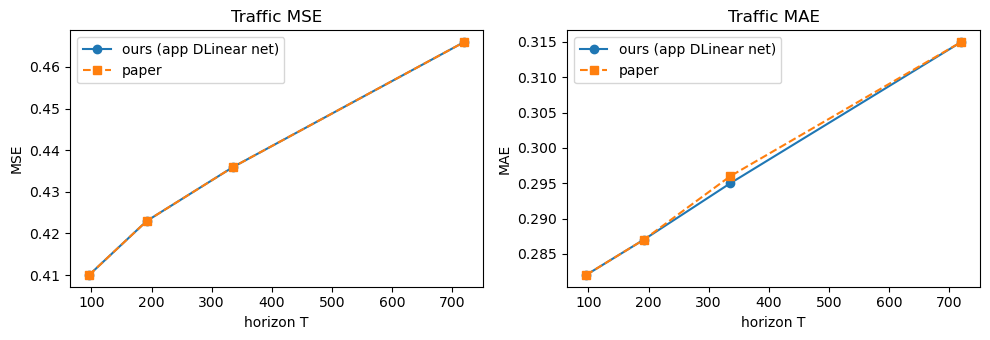

In [11]:
tol = 5.0
ok = (paper_df.MSE_diff_pct.abs() <= tol) & (paper_df.MAE_diff_pct.abs() <= tol)
trend = paper_df.ours_MSE.is_monotonic_increasing
print(paper_df[["horizon","ours_MSE","paper_MSE","MSE_diff_pct","ours_MAE","paper_MAE","MAE_diff_pct"]].to_string(index=False))
print()
print(f"Within +/-{tol}% of the paper at every horizon: {bool(ok.all())}")
print(f"MSE increases with horizon like the paper:     {bool(trend)}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
for a, k, p in zip(ax, ["MSE", "MAE"], ["paper_MSE", "paper_MAE"]):
    a.plot(paper_df.horizon.values, paper_df[f"ours_{k}"].values, "o-", label="ours (app DLinear net)")
    a.plot(paper_df.horizon.values, paper_df[p].values, "s--", label="paper")
    a.set_xlabel("horizon T"); a.set_ylabel(k); a.set_title(f"Traffic {k}"); a.legend()
plt.tight_layout(); plt.show()

## 8. Why the app reports lower MSE: same models, different test protocol

The app scores **one** window: the `seq_len` rows right before the test region predict the next `pred_len`
rows. Below, the model trained in section 6 is evaluated on (a) the paper's all-windows average and
(b) only that single first test window, and the spread of per-window MSE is shown.
A single window can land anywhere in this distribution, so one number says little about the model.

,horizon,all_windows_MSE,single_first_window_MSE,min_window,median_window,p90_window,max_window
0,96,0.410,0.311,0.212,0.361,0.613,1.165
1,192,0.423,0.355,0.282,0.385,0.591,0.769
2,336,0.436,0.343,0.314,0.409,0.568,0.752
3,720,0.466,0.412,0.339,0.445,0.597,0.691


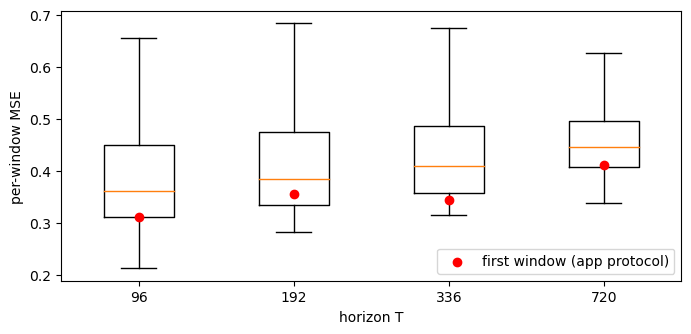

In [12]:
rows = []
for T in CFG["pred_lens"]:
    pw = perwin[T]
    rows.append(dict(horizon=T, all_windows_MSE=pw.mean(), single_first_window_MSE=pw[0],
                     min_window=pw.min(), median_window=np.median(pw), p90_window=np.percentile(pw, 90), max_window=pw.max()))
spread = pd.DataFrame(rows).round(3); display(spread)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.boxplot([perwin[T] for T in CFG["pred_lens"]], labels=CFG["pred_lens"], showfliers=False)
ax.scatter(range(1, 5), [perwin[T][0] for T in CFG["pred_lens"]], c="r", zorder=3, label="first window (app protocol)")
ax.set_xlabel("horizon T"); ax.set_ylabel("per-window MSE"); ax.legend(); plt.show()

## 9. Why the app reports lower MSE (2): only 50 of 862 sensors

The app keeps the first 50 sensors (`max_vars=50`), so the metric is averaged over a different, smaller set of
channels. Same protocol as section 6 (all windows), T = 96 and 720, retrained on the 50-sensor subset.

In [13]:
sub = raw[:, :50]
(tr50, va50, te50), _ = paper_split(sub, L)
rows = []
for T in [96, 720]:
    m, hist = train_dlinear(tr50, va50, L, T, 50, cfg, verbose=False)
    mse, mae, pw = evaluate(m, torch.from_numpy(te50), L, T)
    full = paper_df.loc[paper_df.horizon == T, "ours_MSE"].item()
    rows.append(dict(horizon=T, MSE_50_sensors=mse, MAE_50_sensors=mae, MSE_862_sensors=full, paper_MSE=PAPER[T][0]))
display(pd.DataFrame(rows).round(3))

,horizon,MSE_50_sensors,MAE_50_sensors,MSE_862_sensors,paper_MSE
0,96,0.293,0.261,0.410,0.410
1,720,0.332,0.293,0.466,0.466


## 10. Conclusions

*(see the printed tables above)*